In [1]:
from utils import *


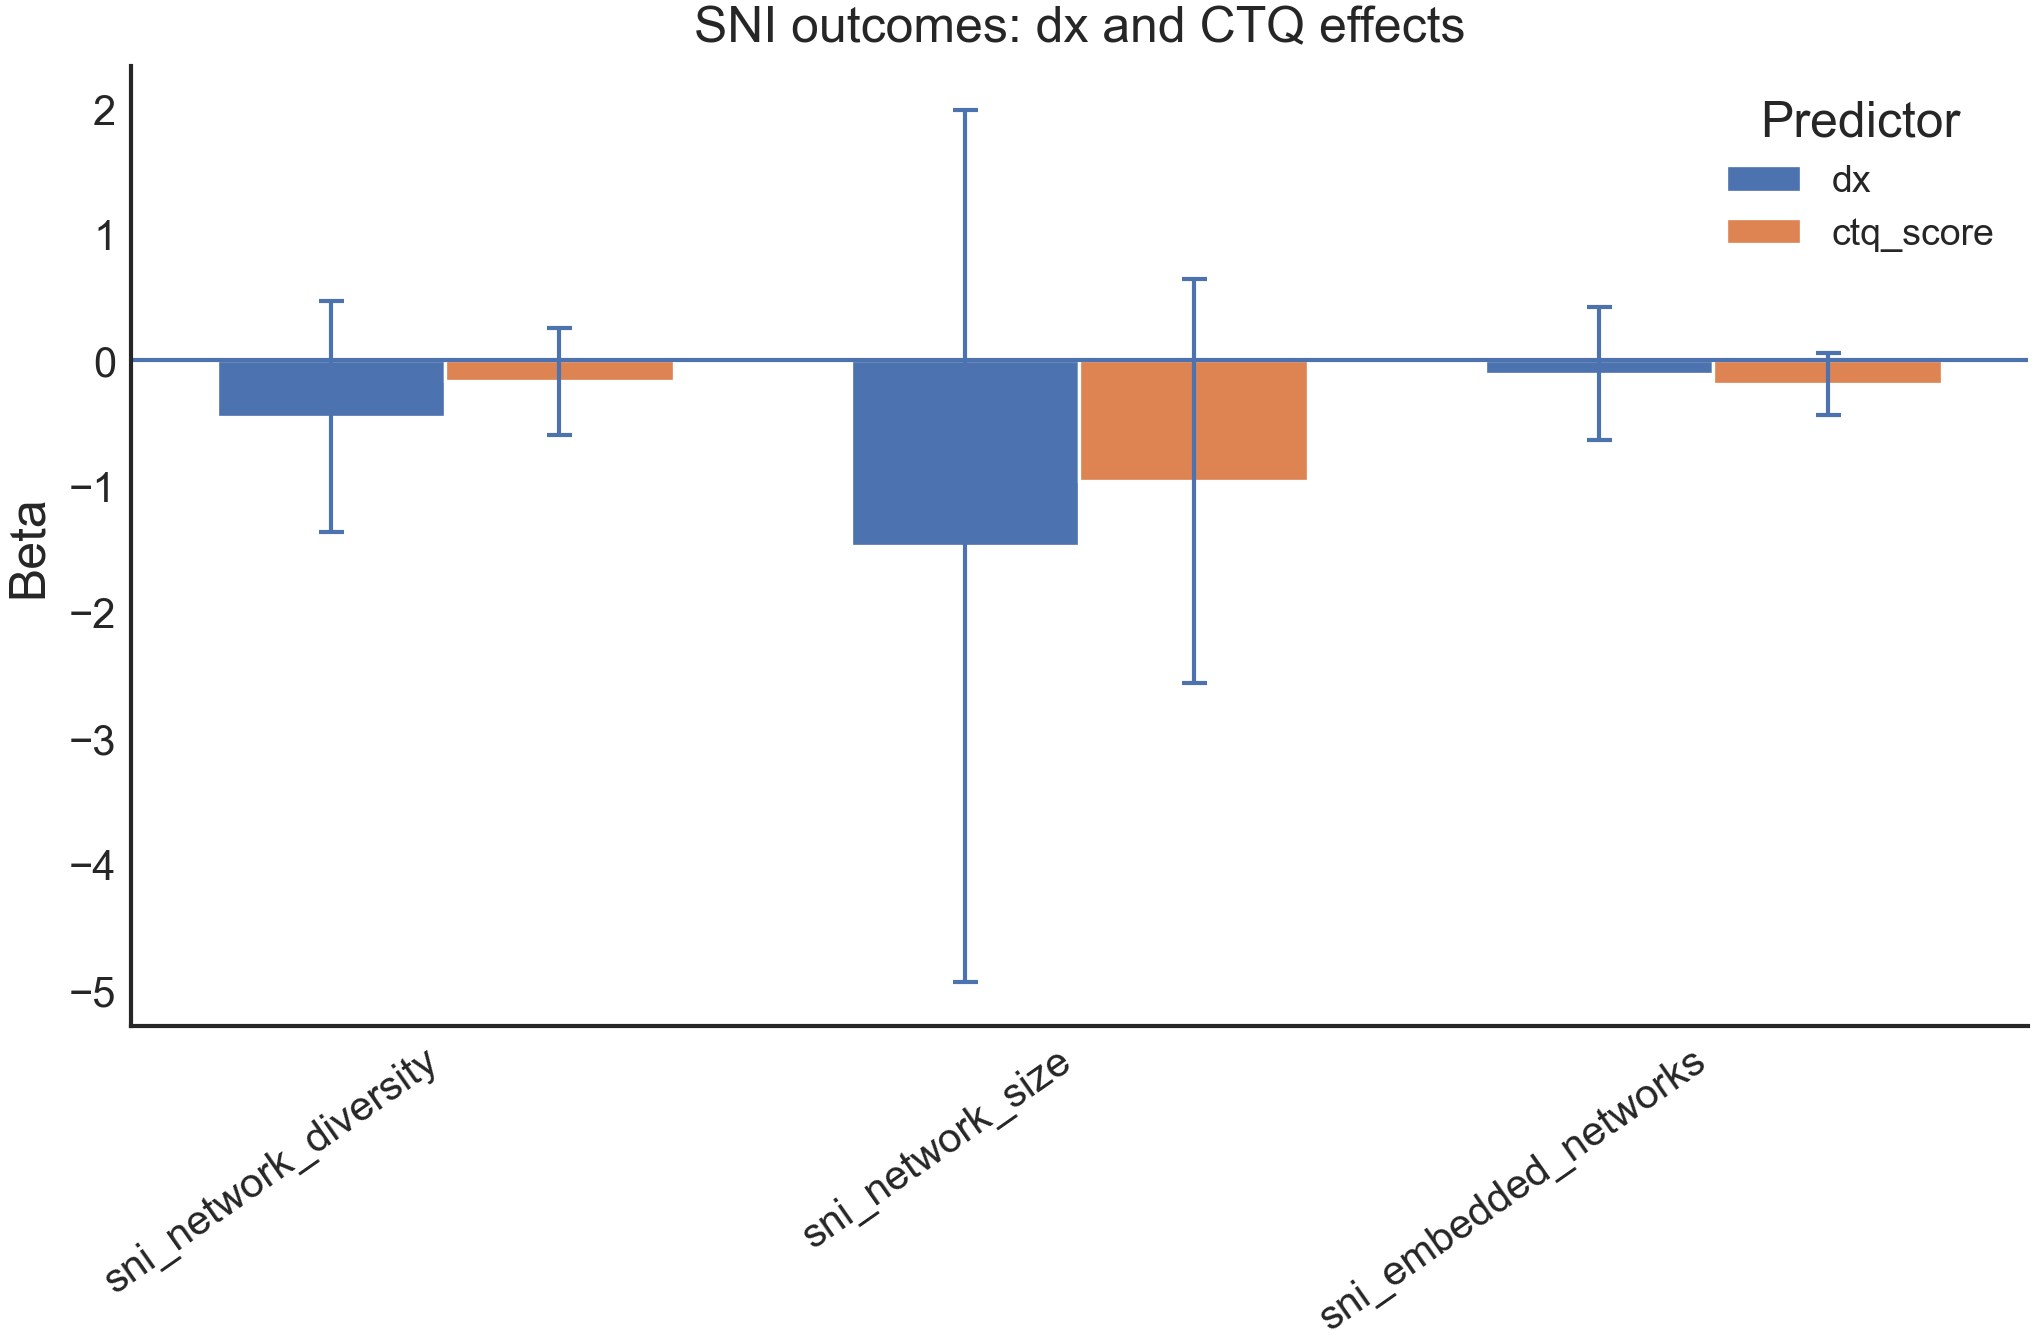

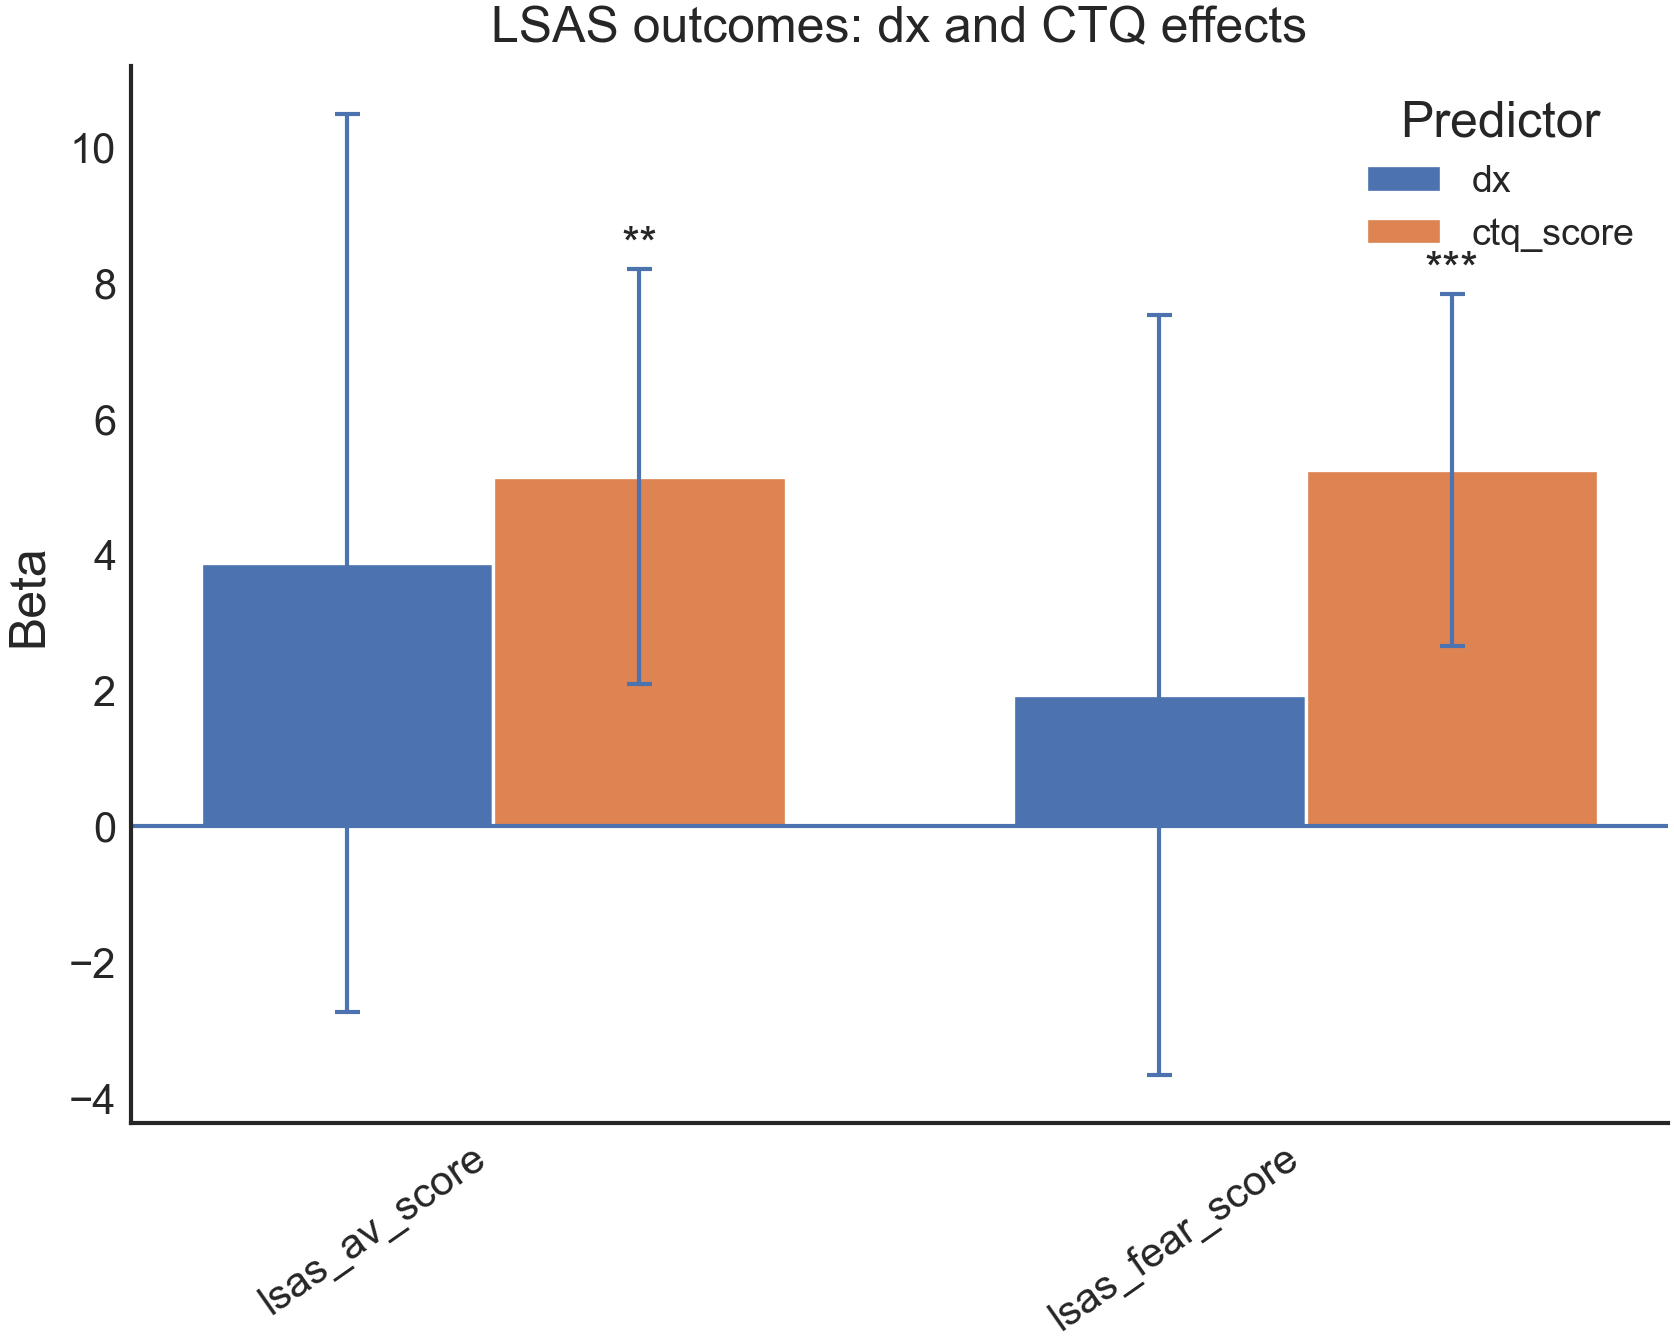

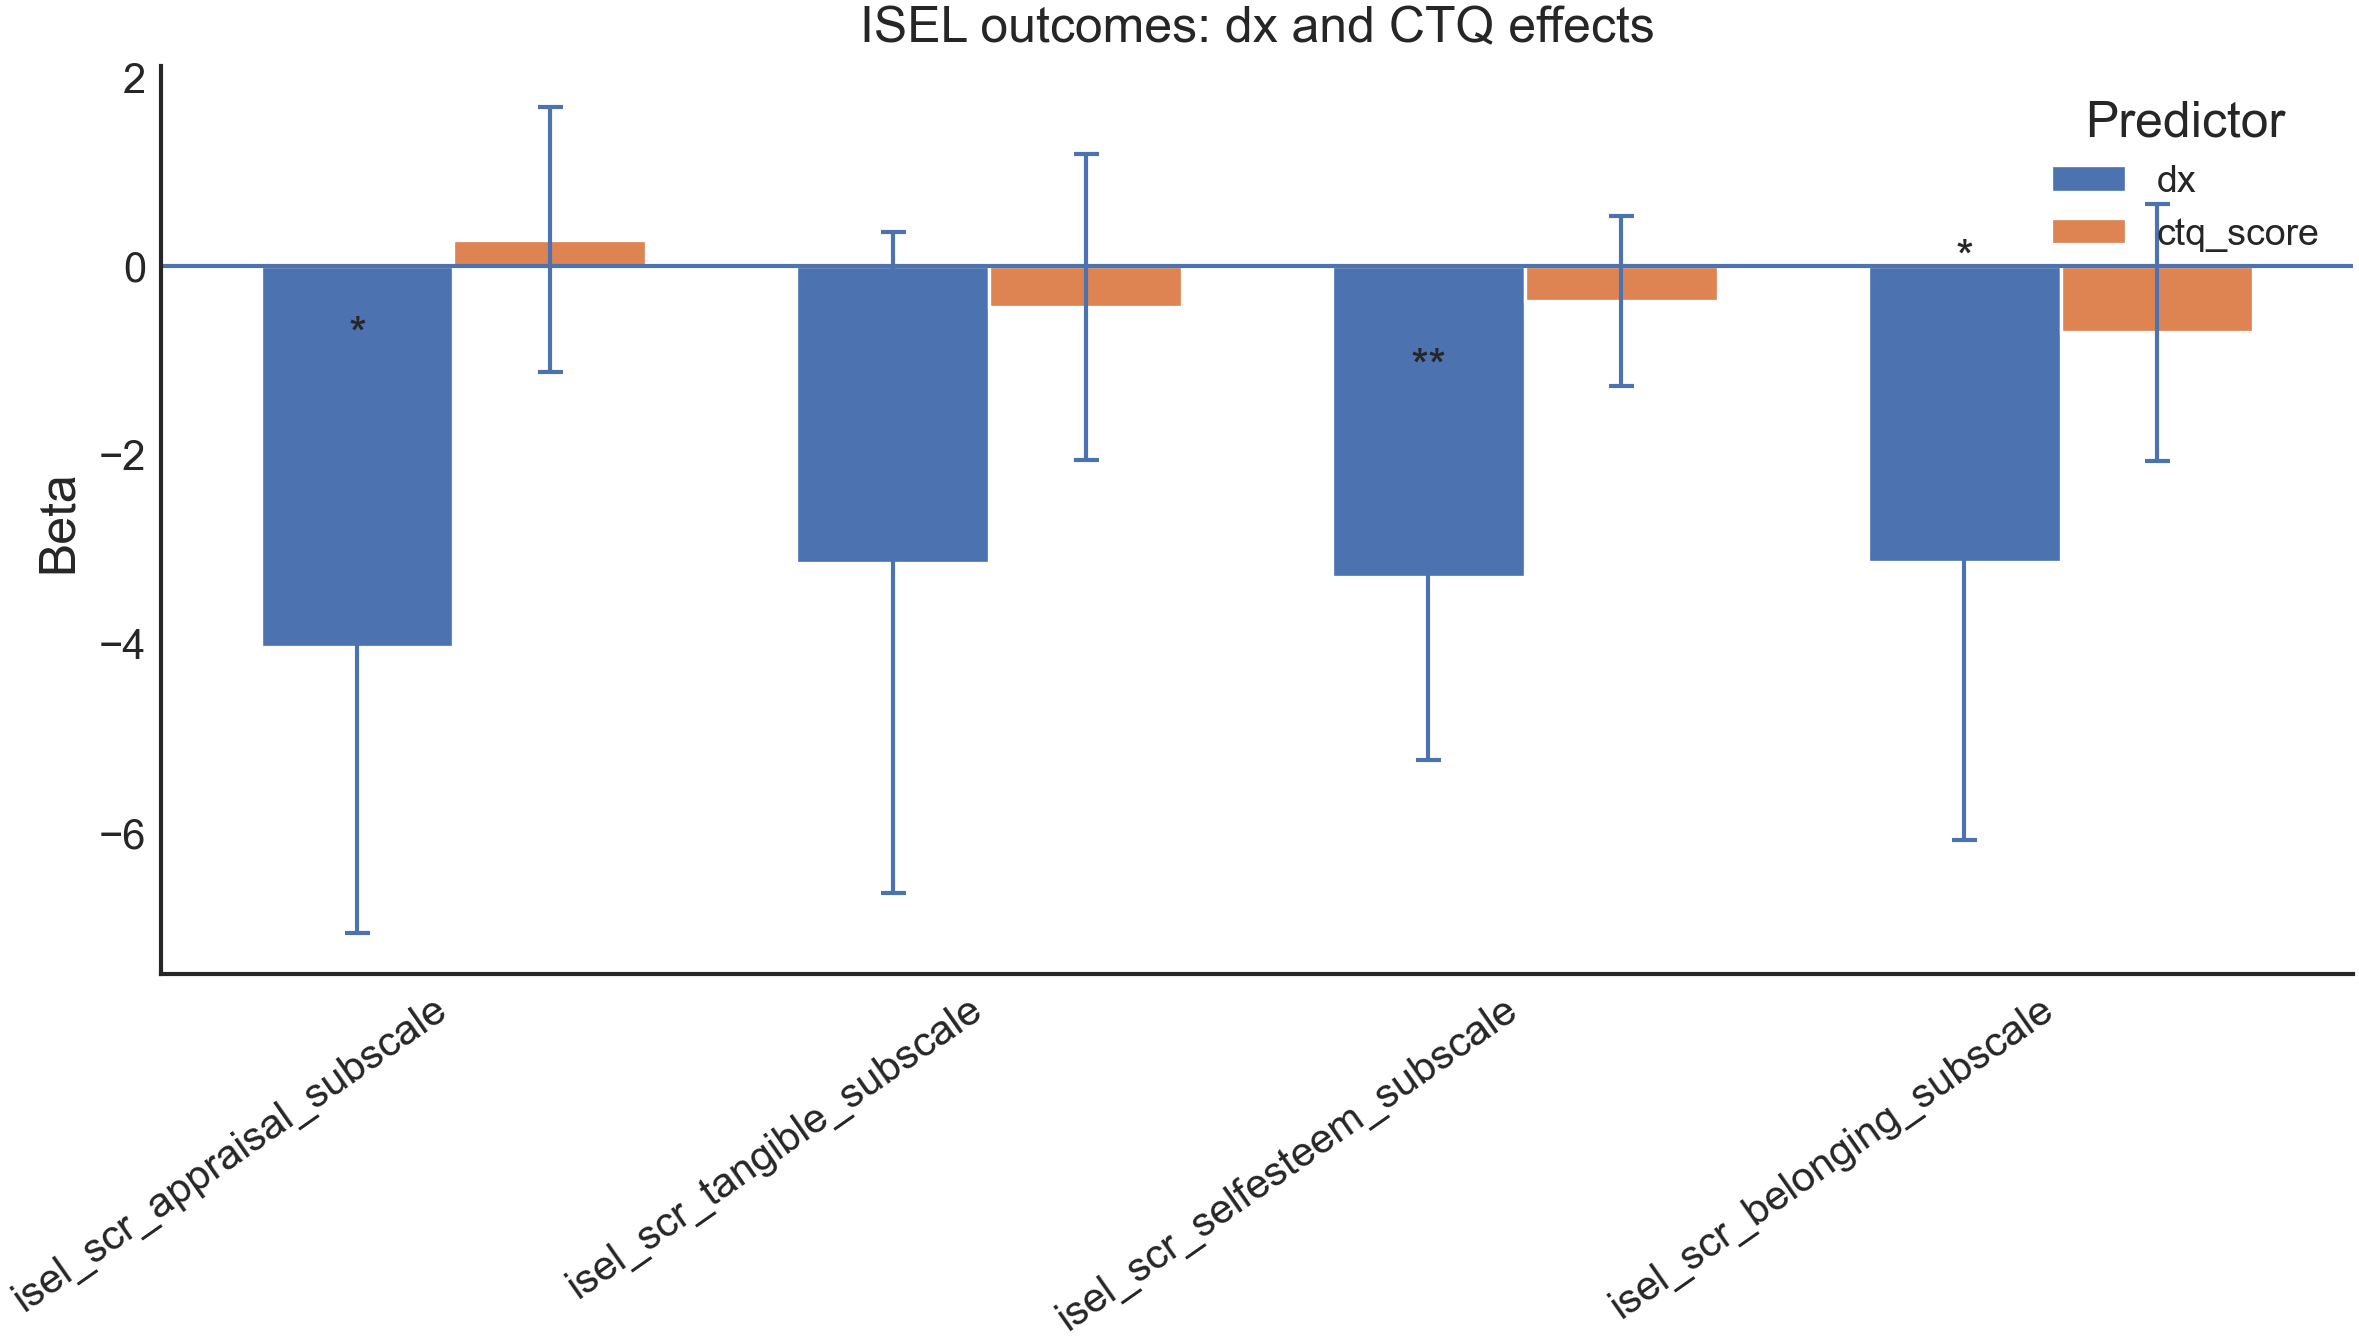

In [ ]:
def extract_dx_ctq(
    reg_df: pd.DataFrame,
    terms=("dx", "ctq_score"),
    *,
    y_col="y",
    x_col="x",
    beta_col="beta",
    lb_col="95%_lb",
    ub_col="95%_ub",
    p_col="p",
) -> pd.DataFrame:
    """
    Extract beta / CI / p for requested terms (default: dx, ctq_score)
    from a single run_regression() output dataframe.

    Returns a tidy dataframe with one row per term:
      outcome, term, beta, ci_lb, ci_ub, p
    """
    required = {y_col, x_col, beta_col, lb_col, ub_col, p_col}
    missing = required - set(reg_df.columns)
    if missing:
        raise ValueError(
            f"reg_df missing expected columns: {sorted(missing)}. "
            f"Present columns: {list(reg_df.columns)}"
        )

    # outcome name is repeated per row; take the first non-null
    outcome = reg_df[y_col].dropna().iloc[0] if reg_df[y_col].notna().any() else None

    rows = []
    for term in terms:
        sub = reg_df.loc[reg_df[x_col] == term]
        if sub.empty:
            rows.append(
                dict(
                    outcome=outcome,
                    term=term,
                    beta=np.nan,
                    ci_lb=np.nan,
                    ci_ub=np.nan,
                    p=np.nan,
                )
            )
        else:
            r = sub.iloc[0]
            rows.append(
                dict(
                    outcome=r[y_col],
                    term=r[x_col],
                    beta=float(r[beta_col]),
                    ci_lb=float(r[lb_col]),
                    ci_ub=float(r[ub_col]),
                    p=float(r[p_col]),
                )
            )

    return pd.DataFrame(rows)

def run_and_extract_dx_ctq(
    outcomes,
    covariates,
    data,
    *,
    run_regression_fn,
    terms=("dx", "ctq_score"),
    p_col="p",  # or "p_left" / "p_right" if you want directional
) -> pd.DataFrame:
    """
    Runs regressions for each outcome and returns a single tidy df
    with dx/ctq_score effects for each outcome.
    """
    out_frames = []
    rhs = " + ".join(covariates)

    for y in outcomes:
        reg_df = run_regression_fn(f"{y} ~ {rhs}", data=data)
        tidy = extract_dx_ctq(reg_df, terms=terms, p_col=p_col)
        out_frames.append(tidy)

    return pd.concat(out_frames, ignore_index=True)

def p_to_stars(p: float) -> str:
    if not np.isfinite(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

def plot_grouped_bars_dx_ctq(
    effects_df: pd.DataFrame,
    *,
    title: str,
    term_order=("dx", "ctq_score"),
    outcome_order=None,
    annotate_p=True,
    ax=None,
):
    """
    effects_df should be tidy output from run_and_extract_dx_ctq() or
    concatenated outputs from extract_dx_ctq(), with columns:
      outcome, term, beta, ci_lb, ci_ub, p
    """
    df = effects_df.copy()

    # enforce order
    if outcome_order is None:
        outcome_order = list(dict.fromkeys(df["outcome"].tolist()))
    df["outcome"] = pd.Categorical(df["outcome"], categories=outcome_order, ordered=True)
    df["term"] = pd.Categorical(df["term"], categories=list(term_order), ordered=True)
    df = df.sort_values(["outcome", "term"])

    outcomes = outcome_order
    x = np.arange(len(outcomes))
    width = 0.36

    if ax is None:
        fig, ax = plt.subplots(figsize=(1.2 * len(outcomes) + 3.5, 4.8))
    else:
        fig = ax.figure

    for i, term in enumerate(term_order):
        sub = df[df["term"] == term].set_index("outcome").reindex(outcomes)

        betas = sub["beta"].to_numpy(dtype=float)
        ci_lb = sub["ci_lb"].to_numpy(dtype=float)
        ci_ub = sub["ci_ub"].to_numpy(dtype=float)

        # asymmetric CI errors
        yerr = np.vstack([betas - ci_lb, ci_ub - betas])

        offset = (i - (len(term_order) - 1) / 2) * width
        xpos = x + offset

        ax.bar(xpos, betas, width=width, label=str(term))
        ax.errorbar(xpos, betas, yerr=yerr, fmt="none", capsize=3)

        if annotate_p:
            ps = sub["p"].to_numpy(dtype=float)
            for xx, yy, pp in zip(xpos, betas, ps):
                s = p_to_stars(pp)
                if s:
                    # place star slightly above upper CI (or above bar if CI missing)
                    y_top = yy
                    if np.isfinite(pp) and np.isfinite(yy):
                        if np.isfinite(ci_ub[np.where(xpos == xx)][0]):
                            y_top = np.nanmax([yy, ci_ub[np.where(xpos == xx)][0]])
                    ax.text(xx, y_top + 0.03, s, ha="center", va="bottom", fontsize=11)

    ax.axhline(0, linewidth=1)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(outcomes, rotation=35, ha="right")
    ax.set_ylabel("Beta")
    ax.legend(title="Predictor", frameon=False)
    fig.tight_layout()

    return fig, ax

sni_cols  = ['sni_network_diversity', 'sni_network_size', 'sni_embedded_networks']
lsas_cols = ['lsas_av_score', 'lsas_fear_score']
isel_cols = ['isel_scr_appraisal_subscale', 'isel_scr_tangible_subscale',
             'isel_scr_selfesteem_subscale', 'isel_scr_belonging_subscale']

# Extract effects (two-sided p-values by default via p_col="p")
sni_eff  = run_and_extract_dx_ctq(sni_cols,  covariates, data, run_regression_fn=run_regression, p_col="p")
lsas_eff = run_and_extract_dx_ctq(lsas_cols, covariates, data, run_regression_fn=run_regression, p_col="p")
isel_eff = run_and_extract_dx_ctq(isel_cols, covariates, data, run_regression_fn=run_regression, p_col="p")

# Plot: one figure per set
plot_grouped_bars_dx_ctq(sni_eff,  title="SNI outcomes: dx and CTQ effects")
plot_grouped_bars_dx_ctq(lsas_eff, title="LSAS outcomes: dx and CTQ effects")
plot_grouped_bars_dx_ctq(isel_eff, title="ISEL outcomes: dx and CTQ effects")

plt.show()

In [23]:
data['iq'] = data['wrat_standard_score']

In [24]:
run_regression('iq ~ ctq_score + dx + sex', data=data)

,y,x,dof,rsq,adj_rsq,bic,aic,beta,se,95%_lb,95%_ub,t,p,p_left,p_right
0,iq,Intercept,75.0,0.096,0.059,581.76,572.28,109.480,1.961,105.575,113.386,55.839,0.000,1.000,0.000
1,iq,ctq_score,75.0,0.096,0.059,581.76,572.28,0.764,1.016,-1.259,2.788,0.753,0.454,0.773,0.227
2,iq,dx,75.0,0.096,0.059,581.76,572.28,-2.138,2.196,-6.513,2.237,-0.973,0.333,0.167,0.833
3,iq,sex,75.0,0.096,0.059,581.76,572.28,-6.351,2.274,-10.881,-1.821,-2.793,0.007,0.003,0.997
